Ваша задача обучить модель классификации комментариев на позитивные и негативные. Для этого предлагается использовать набор данных с разметкой о токсичности текста.
Для того, чтобы решить данную задачу Вам требуется:
1. Предобработать данные
  * Обосновать выбор методов предобработки текста
2. Векторизовать текст
3. Подобрать параметры и обучить модель (Можно использовать BERT)
4. Убедиться, что F1 не менее 0.75

Данная лабораторная работа была вдохновлена [статьей](https://habr.com/ru/articles/655517/), потому что тяжело без нее было

Предобработаем данные

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/My Drive/comments.csv')
df

,Unnamed: 0,text,toxic
0,0,Explanation\nWhy the edits made under my usern...,0
1,1,D'aww! He matches this background colour I'm s...,0
2,2,"Hey man, I'm really not trying to edit war. It...",0
3,3,"""\nMore\nI can't make any real suggestions on ...",0
4,4,"You, sir, are my hero. Any chance you remember...",0
...,...,...,...
159287,159446,""":::::And for the second time of asking, when ...",0
159288,159447,You should be ashamed of yourself \n\nThat is ...,0
159289,159448,"Spitzer \n\nUmm, theres no actual article for ...",0
159290,159449,And it looks like it was actually you who put ...,0


Проверяем, есть ли пропуски

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
text,0
toxic,0


Смотрим на дубликаты

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  159292 non-null  int64 
 1   text        159292 non-null  object
 2   toxic       159292 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ MB


Удалим непонятную колонку без названия

In [ ]:
df=df.drop(columns=['Unnamed: 0'])

In [ ]:
df.describe()

,toxic
count,159292.000000
mean,0.101612
std,0.302139
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


Посмотрим сколько относится токсичным, а сколько к нетоксичным

In [ ]:
df['toxic'].value_counts()

,count
toxic,
0,143106
1,16186


<Axes: >

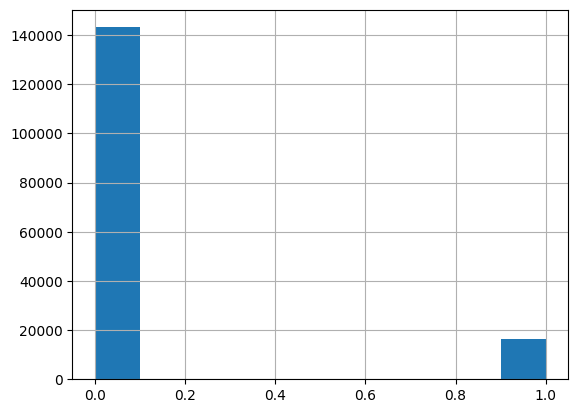

In [ ]:
df['toxic'].hist()


Чистим текст. Приводим к нижнему регистру и удаляем все символы кроме русских букв и пробелов.

In [ ]:
df['text'] = df['text'].str.lower()

In [ ]:
df['text'] = df['text'].str.replace('[^а-яё ]', '', regex=True)

Разделим на выборки. Разделение на train (80%), validation (10%) и test (10%)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['toxic'], test_size=0.2, random_state=42)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# vectorizer = TfidfVectorizer(max_features=1000)
# X_train_vec = vectorizer.fit_transform(X_train)
# X_test_vec = vectorizer.transform(X_test)

Загрузим предобученный русский BERT и его токенизатор

In [ ]:
from transformers import AutoModel, BertTokenizer, BertForSequenceClassification

In [ ]:
model_name = 'DeepPavlov/rubert-base-cased'
tokenizer = BertTokenizer.from_pretrained(model_name)
bert = AutoModel.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Проведем токенизацию текстов

In [ ]:
import torch
import transformers
import torch.nn as nn

In [ ]:
def prepare_data(texts, labels, tokenizer, max_len=128):
    encoded = tokenizer.batch_encode_plus(
        texts.tolist(),
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_token_type_ids=False
    )

    input_ids = torch.tensor(encoded['input_ids'])
    attention_mask = torch.tensor(encoded['attention_mask'])
    labels = torch.tensor(labels.tolist())

    return input_ids, attention_mask, labels

In [ ]:
train_ids, train_mask, train_y = prepare_data(X_train, y_train, tokenizer)
val_ids, val_mask, val_y = prepare_data(X_val, y_val, tokenizer)
test_ids, test_mask, test_y = prepare_data(X_test, y_test, tokenizer)

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

In [ ]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

In [ ]:
Указываем размер батчей и создаем даталоудер для обработки

In [ ]:
batch_size = 128

train_data = TensorDataset(train_ids, train_mask, train_y)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size, num_workers=2, pin_memory=True)

In [ ]:
val_data = TensorDataset(val_ids, val_mask, val_y)
val_sampler = SequentialSampler(val_data)
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=batch_size)

In [ ]:
test_data = TensorDataset(test_ids, test_mask, test_y)
test_sampler = SequentialSampler(test_data)
test_dataloader = DataLoader(test_data, sampler=test_sampler, batch_size=batch_size)

Архитектура модели. Добавили dropout, чтобы не было переобучения, а полносвязные слои - так как у нас задача классификации



In [ ]:
class BERT_Arch(nn.Module):
    def __init__(self, bert):
        super(BERT_Arch, self).__init__()
        self.bert = bert
        self.dropout = nn.Dropout(0.1)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(768, 512)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, sent_id, mask):
        _, cls_hs = self.bert(sent_id, attention_mask=mask, return_dict=False)
        x = self.fc1(cls_hs)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
model = BERT_Arch(bert).to(device)

Настраиваем обучение

In [ ]:
for param in bert.parameters():
    param.requires_grad = False

In [ ]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

In [ ]:
from torch.optim import AdamW
from sklearn.utils.class_weight import compute_class_weight

Замораживаем BERT, чтобы не трогать веса. Также настраиваем оптимизатор и функции потерь

In [ ]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)


In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)

In [ ]:
from tqdm import tqdm

In [ ]:
def train():
    model.train()
    total_loss, total_accuracy = 0, 0
    total_preds = []

    for step, batch in enumerate(train_dataloader):
        if step % 100 == 0:
            tqdm.write(f"[Train] Step {step}/{len(train_dataloader)}")

        batch = [r.to(device) for r in batch]
        sent_id, mask, labels = batch

        model.zero_grad()
        preds = model(sent_id, mask)
        loss = criterion(preds, labels)
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        preds = preds.detach().cpu().numpy()
        total_preds.append(preds)

    avg_loss = total_loss / len(train_dataloader)
    total_preds = np.concatenate(total_preds, axis=0)
    return avg_loss, total_preds

In [ ]:
def evaluate(dataloader):
    model.eval()
    total_loss, total_accuracy = 0, 0
    total_preds = []

    for step, batch in enumerate(test_dataloader):
        if step % 100 == 0:
            tqdm.write(f"[Val] Step {step}/{len(test_dataloader)}")
        batch = [t.to(device) for t in batch]
        sent_id, mask, labels = batch

        with torch.no_grad():
            preds = model(sent_id, mask)
            loss = criterion(preds, labels)
            total_loss += loss.item()
            preds = preds.detach().cpu().numpy()
            total_preds.append(preds)

    avg_loss = total_loss / len(dataloader)
    total_preds = np.concatenate(total_preds, axis=0)
    return avg_loss, total_preds

Обучаем

In [ ]:
epochs = 3
best_valid_loss = float('inf')
train_losses = []
valid_losses = []

In [ ]:
for epoch in range(epochs):
    print(f'\n Epoch {epoch + 1} / {epochs}')

    train_loss, _ = train()
    valid_loss, _ = evaluate(val_dataloader)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_model.pt')

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f'\nTraining Loss: {train_loss:.3f}')
    print(f'Validation Loss: {valid_loss:.3f}')


 Epoch 1 / 3
[Train] Step 0/996
[Train] Step 100/996
[Train] Step 200/996
[Train] Step 300/996
[Train] Step 400/996
[Train] Step 500/996
[Train] Step 600/996
[Train] Step 700/996
[Train] Step 800/996
[Train] Step 900/996
[Val] Step 0/125
[Val] Step 100/125

Training Loss: 0.694
Validation Loss: 0.694

 Epoch 2 / 3
[Train] Step 0/996
[Train] Step 100/996
[Train] Step 200/996
[Train] Step 300/996
[Train] Step 400/996
[Train] Step 500/996
[Train] Step 600/996
[Train] Step 700/996
[Train] Step 800/996
[Train] Step 900/996
[Val] Step 0/125
[Val] Step 100/125

Training Loss: 0.694
Validation Loss: 0.694

 Epoch 3 / 3
[Train] Step 0/996
[Train] Step 100/996
[Train] Step 200/996
[Train] Step 300/996
[Train] Step 400/996
[Train] Step 500/996
[Train] Step 600/996
[Train] Step 700/996
[Train] Step 800/996
[Train] Step 900/996
[Val] Step 0/125
[Val] Step 100/125

Training Loss: 0.694
Validation Loss: 0.693


In [ ]:
model.load_state_dict(torch.load('best_model.pt'))

<All keys matched successfully>

In [ ]:
test_loss, test_preds = evaluate(test_dataloader)

[Val] Step 0/125
[Val] Step 100/125


In [ ]:
test_preds = np.argmax(test_preds, axis=1)

In [ ]:
print(f"y_test length: {len(y_test)}")
print(f"test_preds length: {len(test_preds)}")


y_test length: 15930
test_preds length: 15930


Вывод метрик

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score

Видим 0.95 и радуемся

In [ ]:
print(classification_report(y_test, test_preds, target_names=['Non-toxic', 'Toxic']))


              precision    recall  f1-score   support

   Non-toxic       0.90      1.00      0.95     14314
       Toxic       0.06      0.00      0.00      1616

    accuracy                           0.90     15930
   macro avg       0.48      0.50      0.47     15930
weighted avg       0.81      0.90      0.85     15930

